In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Copy of marketing_campaign_dataset.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 57078
Columns: 15


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,01-01-2021,506.0,1922.0,6.0,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,01-02-2021,116.0,7523.0,7.0,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,01-03-2021,584.0,7698.0,1.0,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,01-04-2021,217.0,1820.0,7.0,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,01-05-2021,379.0,4201.0,3.0,Health & Wellness


In [ ]:
# Check data types
print("Data Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Date                 object
Clicks              float64
Impressions         float64
Engagement_Score    float64
Customer_Segment     object
dtype: object

Missing Values:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              1
Impressions         1
Engagement_Score    1
Customer_Segment    1
dtype: int64


In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing numerical values with median
df['Engagement_Score'] = df['Engagement_Score'].fillna(
    df['Engagement_Score'].median()
)

# Fill missing categorical values with mode
df['Customer_Segment'] = df['Customer_Segment'].fillna(
    df['Customer_Segment'].mode()[0]
)

# Check again
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              1
Impressions         1
Engagement_Score    1
Customer_Segment    1
dtype: int64

Missing values after cleaning:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              1
Impressions         1
Engagement_Score    0
Customer_Segment    0
dtype: int64


In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert Acquisition Cost to numeric
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Convert Duration from "30 days" to numeric days
df['Duration_Days'] = (
    df['Duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

# Check the data types
print(df.dtypes)

Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                    object
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                    object
Date                datetime64[ns]
Clicks                     float64
Impressions                float64
Engagement_Score           float64
Customer_Segment            object
Duration_Days                int64
dtype: object


In [ ]:
# Basic statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Date,Clicks,Impressions,Engagement_Score,Duration_Days
count,57078.000000,57078.000000,57078.000000,57078.000000,22524,57077.000000,57077.000000,57078.000000,57078.000000
mean,28539.500000,0.080244,12509.905288,5.008184,2021-06-21 17:11:28.545551616,548.381765,5503.033691,5.497372,37.524177
min,1.000000,0.010000,5000.000000,2.000000,2021-01-01 00:00:00,100.000000,1000.000000,1.000000,15.000000
25%,14270.250000,0.050000,8754.000000,3.510000,2021-03-12 00:00:00,323.000000,3266.000000,3.000000,30.000000
50%,28539.500000,0.080000,12515.500000,5.010000,2021-06-12 00:00:00,548.000000,5506.000000,6.000000,45.000000
75%,42808.750000,0.120000,16254.000000,6.510000,2021-09-12 00:00:00,774.000000,7756.000000,8.000000,45.000000
max,57078.000000,0.150000,20000.000000,8.000000,2021-12-12 00:00:00,1000.000000,10000.000000,10.000000,60.000000
std,16477.143669,0.040670,4340.314435,1.734637,NaN,259.726323,2597.090411,2.870633,16.733459


In [ ]:
# Key business metrics
print("Total Campaigns:", len(df))
print("Average ROI:", round(df['ROI'].mean(), 2))
print("Average Conversion Rate:", round(df['Conversion_Rate'].mean(), 4))
print("Average Acquisition Cost:", round(df['Acquisition_Cost'].mean(), 2))
print("Average Engagement Score:", round(df['Engagement_Score'].mean(), 2))

Total Campaigns: 57078
Average ROI: 5.01
Average Conversion Rate: 0.0802
Average Acquisition Cost: 12509.91
Average Engagement Score: 5.5


In [ ]:
# Channel-wise performance analysis

channel_analysis = df.groupby('Channel_Used').agg(
    Campaigns=('Campaign_ID', 'count'),
    Average_ROI=('ROI', 'mean'),
    Average_Conversion_Rate=('Conversion_Rate', 'mean'),
    Average_Acquisition_Cost=('Acquisition_Cost', 'mean'),
    Average_Engagement=('Engagement_Score', 'mean')
).sort_values('Average_ROI', ascending=False)

display(channel_analysis)

,Campaigns,Average_ROI,Average_Conversion_Rate,Average_Acquisition_Cost,Average_Engagement
Channel_Used,,,,,
Email,9523,5.020853,0.080385,12550.195107,5.465820
Website,9601,5.019433,0.080386,12460.970003,5.495678
Google Ads,9427,5.015031,0.080997,12506.723666,5.502917
Facebook,9445,5.008198,0.080097,12540.729804,5.493383
YouTube,9531,5.005115,0.079814,12481.898122,5.499213
Instagram,9551,4.980537,0.079790,12519.531463,5.527170


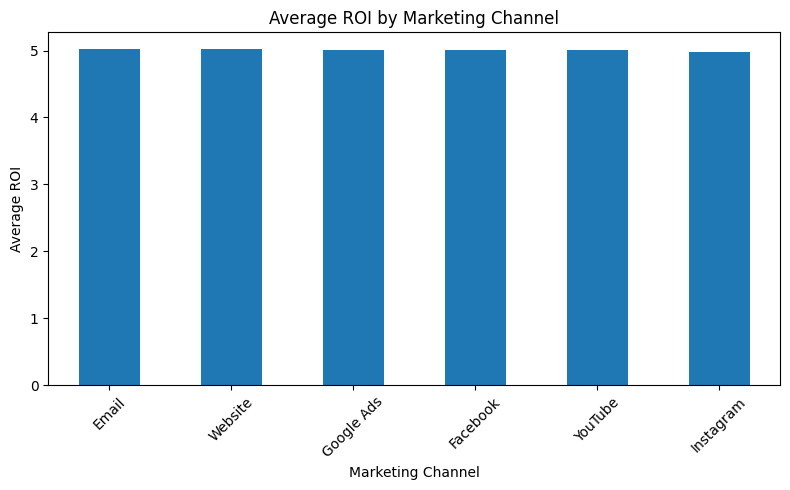

In [ ]:
import matplotlib.pyplot as plt

channel_analysis['Average_ROI'].plot(
    kind='bar',
    figsize=(8,5),
    title='Average ROI by Marketing Channel'
)

plt.xlabel('Marketing Channel')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Conversion rate by marketing channel

conversion_analysis = df.groupby('Channel_Used').agg(
    Average_Conversion_Rate=('Conversion_Rate', 'mean'),
    Average_ROI=('ROI', 'mean')
).sort_values('Average_Conversion_Rate', ascending=False)

display(conversion_analysis)

,Average_Conversion_Rate,Average_ROI
Channel_Used,,
Google Ads,0.080997,5.015031
Website,0.080386,5.019433
Email,0.080385,5.020853
Facebook,0.080097,5.008198
YouTube,0.079814,5.005115
Instagram,0.079790,4.980537


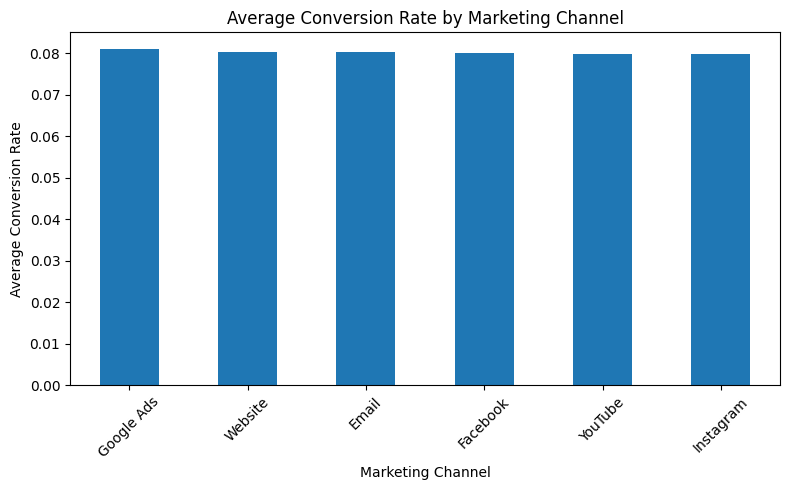

In [ ]:
import matplotlib.pyplot as plt

conversion_analysis['Average_Conversion_Rate'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Conversion Rate by Marketing Channel'
)

plt.xlabel('Marketing Channel')
plt.ylabel('Average Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Acquisition cost by marketing channel

cost_analysis = df.groupby('Channel_Used').agg(
    Average_Acquisition_Cost=('Acquisition_Cost', 'mean'),
    Average_ROI=('ROI', 'mean'),
    Average_Conversion_Rate=('Conversion_Rate', 'mean')
).sort_values('Average_Acquisition_Cost')

display(cost_analysis)

,Average_Acquisition_Cost,Average_ROI,Average_Conversion_Rate
Channel_Used,,,
Website,12460.970003,5.019433,0.080386
YouTube,12481.898122,5.005115,0.079814
Google Ads,12506.723666,5.015031,0.080997
Instagram,12519.531463,4.980537,0.079790
Facebook,12540.729804,5.008198,0.080097
Email,12550.195107,5.020853,0.080385


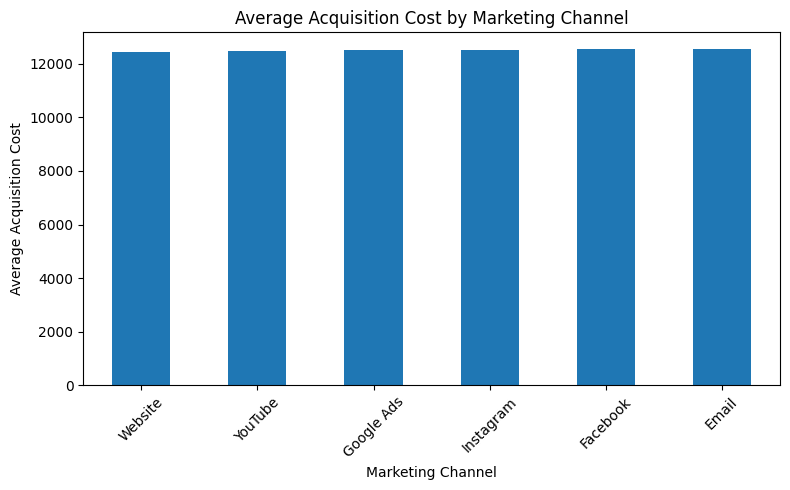

In [ ]:
import matplotlib.pyplot as plt

cost_analysis['Average_Acquisition_Cost'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Acquisition Cost by Marketing Channel'
)

plt.xlabel('Marketing Channel')
plt.ylabel('Average Acquisition Cost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ROI vs Acquisition Cost by Marketing Channel

channel_performance = df.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Acquisition_Cost': 'mean'
}).sort_values('ROI', ascending=False)

channel_performance

,ROI,Acquisition_Cost
Channel_Used,,
Email,5.020853,12550.195107
Website,5.019433,12460.970003
Google Ads,5.015031,12506.723666
Facebook,5.008198,12540.729804
YouTube,5.005115,12481.898122
Instagram,4.980537,12519.531463


In [ ]:
# Marketing Channel Performance Summary

channel_summary = df.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'Acquisition_Cost': 'mean',
    'Engagement_Score': 'mean'
}).round(3)

channel_summary = channel_summary.sort_values('ROI', ascending=False)

channel_summary

,ROI,Conversion_Rate,Acquisition_Cost,Engagement_Score
Channel_Used,,,,
Email,5.021,0.080,12550.195,5.466
Website,5.019,0.080,12460.970,5.496
Google Ads,5.015,0.081,12506.724,5.503
Facebook,5.008,0.080,12540.730,5.493
YouTube,5.005,0.080,12481.898,5.499
Instagram,4.981,0.080,12519.531,5.527


In [ ]:
# Business Insights & Recommendations

print("1. Email marketing shows the highest average ROI, making it the strongest channel for return on investment.")

print("2. Google Ads has the highest average conversion rate, indicating strong potential for converting customers.")

print("3. Website marketing has the lowest average acquisition cost, making it a cost-efficient channel.")

print("4. Instagram has the highest engagement score but the lowest average ROI, suggesting that high engagement does not necessarily result in high returns.")

print("5. The company should prioritize Email and Google Ads for performance, while continuing to optimize Website campaigns for cost efficiency.")

print("6. Marketing budgets should be allocated based on a combination of ROI, conversion rate, acquisition cost, and engagement rather than a single metric.")

print("\nFinal Recommendation:")
print("Increase investment in high-performing channels such as Email and Google Ads, maintain Website campaigns because of their lower acquisition cost, and optimize Instagram campaigns to improve ROI.")

1. Email marketing shows the highest average ROI, making it the strongest channel for return on investment.
2. Google Ads has the highest average conversion rate, indicating strong potential for converting customers.
3. Website marketing has the lowest average acquisition cost, making it a cost-efficient channel.
4. Instagram has the highest engagement score but the lowest average ROI, suggesting that high engagement does not necessarily result in high returns.
5. The company should prioritize Email and Google Ads for performance, while continuing to optimize Website campaigns for cost efficiency.
6. Marketing budgets should be allocated based on a combination of ROI, conversion rate, acquisition cost, and engagement rather than a single metric.

Final Recommendation:
Increase investment in high-performing channels such as Email and Google Ads, maintain Website campaigns because of their lower acquisition cost, and optimize Instagram campaigns to improve ROI.


In [ ]:
# Data Cleaning

# Fill missing numerical value with median
df['Engagement_Score'] = df['Engagement_Score'].fillna(
    df['Engagement_Score'].median()
)

# Fill missing categorical value with mode
df['Customer_Segment'] = df['Customer_Segment'].fillna(
    df['Customer_Segment'].mode()[0]
)

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Campaign_ID             0
Company                 0
Campaign_Type           0
Target_Audience         0
Duration                0
Channel_Used            0
Conversion_Rate         0
Acquisition_Cost        0
ROI                     0
Location                0
Date                34554
Clicks                  1
Impressions             1
Engagement_Score        0
Customer_Segment        0
Duration_Days           0
dtype: int64


In [ ]:
print("Dataset shape:", df.shape)
print("Number of rows:", len(df))

Dataset shape: (57078, 16)
Number of rows: 57078


In [ ]:
print(df[['Date', 'Clicks', 'Impressions']].isnull().sum())

Date           34554
Clicks             1
Impressions        1
dtype: int64


In [ ]:
print(df['Date'].head(10))
print(df['Date'].dtype)

0   2021-01-01
1   2021-01-02
2   2021-01-03
3   2021-01-04
4   2021-01-05
5   2021-01-06
6   2021-01-07
7   2021-01-08
8   2021-01-09
9   2021-01-10
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
print(df[['Clicks', 'Impressions']].describe())

             Clicks   Impressions
count  57077.000000  57077.000000
mean     548.381765   5503.033691
std      259.726323   2597.090411
min      100.000000   1000.000000
25%      323.000000   3266.000000
50%      548.000000   5506.000000
75%      774.000000   7756.000000
max     1000.000000  10000.000000


In [ ]:
# Data Cleaning

# Remove rows where Date is missing
df = df.dropna(subset=['Date']).copy()

# Fill missing Clicks and Impressions with their median values
df['Clicks'] = df['Clicks'].fillna(df['Clicks'].median())
df['Impressions'] = df['Impressions'].fillna(df['Impressions'].median())

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df[['Date', 'Clicks', 'Impressions']].isnull().sum())

print("\nDataset shape after cleaning:")
print(df.shape)

Missing values after cleaning:
Date           0
Clicks         0
Impressions    0
dtype: int64

Dataset shape after cleaning:
(22524, 16)


In [ ]:
# Marketing Funnel Analysis

import plotly.graph_objects as go

# Calculate funnel metrics
total_impressions = df['Impressions'].sum()
total_clicks = df['Clicks'].sum()

# Estimate conversions using clicks × conversion rate
total_conversions = (df['Clicks'] * df['Conversion_Rate']).sum()

funnel_data = {
    'Impressions': total_impressions,
    'Clicks': total_clicks,
    'Conversions': total_conversions
}

print("Marketing Funnel:")
print(f"Impressions: {total_impressions:,.0f}")
print(f"Clicks: {total_clicks:,.0f}")
print(f"Conversions: {total_conversions:,.0f}")

# Funnel chart
fig = go.Figure(go.Funnel(
    y=list(funnel_data.keys()),
    x=list(funnel_data.values()),
    textinfo="value+percent initial"
))

fig.update_layout(
    title="Marketing Funnel: Impressions → Clicks → Conversions",
    height=500
)

fig.show()

Marketing Funnel:
Impressions: 124,443,784
Clicks: 12,351,118
Conversions: 991,104


## Marketing Funnel Insights

The marketing funnel shows the customer journey from impressions to clicks and finally conversions. A large number of impressions indicates strong campaign reach, while the number of clicks reflects user interest. The conversion stage indicates how effectively the campaigns turn interested users into customers.

The funnel helps identify potential drop-offs in the customer journey and provides a basis for improving campaign performance and conversion efficiency.

# Business Insights Report – Marketing Campaign Analysis

## Overview
The marketing campaign dataset was analyzed to evaluate the performance of different marketing channels based on ROI, conversion rate, acquisition cost, and engagement score.

## Key Business Insights

1. Email marketing has the highest average ROI (5.021), making it the strongest channel for return on investment.

2. Google Ads has the highest average conversion rate (0.081), indicating strong potential for converting customers.

3. Website marketing has the lowest average acquisition cost (12,460.970), making it the most cost-efficient channel.

4. Instagram has the highest engagement score (5.527), but its ROI is the lowest (4.981). This indicates that high engagement does not always lead to higher financial returns.

5. YouTube has the lowest average ROI (4.9509), suggesting that its campaigns should be reviewed and optimized.

## Budget Recommendation

The company should prioritize **Email and Google Ads** because of their strong ROI and conversion performance. **Website campaigns** should also be maintained because of their lower acquisition cost.

Instagram should be optimized to improve its ROI despite having the highest engagement. YouTube campaigns should be reviewed to identify opportunities for improving financial performance.

## Final Recommendation

Marketing budgets should not be allocated based on a single metric. The company should consider ROI, conversion rate, acquisition cost, and engagement together when making budget decisions. Greater investment should be directed toward high-performing channels such as **Email and Google Ads**, while Website campaigns should be maintained for cost efficiency.